In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load price data
prices = pd.read_parquet("../data/sp500_prices.parquet")
tickers = prices.columns.get_level_values(0).unique()

# Load ticker → sector mapping
tickers_df = pd.read_csv("../data/sp500_tickers.csv")
tickers_df['Symbol'] = tickers_df['Symbol'].str.replace('.', '-')  # match yfinance format
sector_map = dict(zip(tickers_df['Symbol'], tickers_df['GICS Sector']))

# Build a sector-tagged DataFrame of closing prices
closes = pd.DataFrame({t: prices[t]['Close'] for t in tickers})

# Map each ticker to its sector
ticker_sectors = pd.Series({t: sector_map.get(t, 'Unknown') for t in closes.columns})

print(f"Loaded {len(closes.columns)} stocks across {ticker_sectors.nunique()} sectors")
print("\nStocks per sector:")
print(ticker_sectors.value_counts())

Loaded 501 stocks across 11 sectors

Stocks per sector:
Industrials               79
Financials                76
Information Technology    71
Health Care               58
Consumer Discretionary    48
Consumer Staples          36
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64


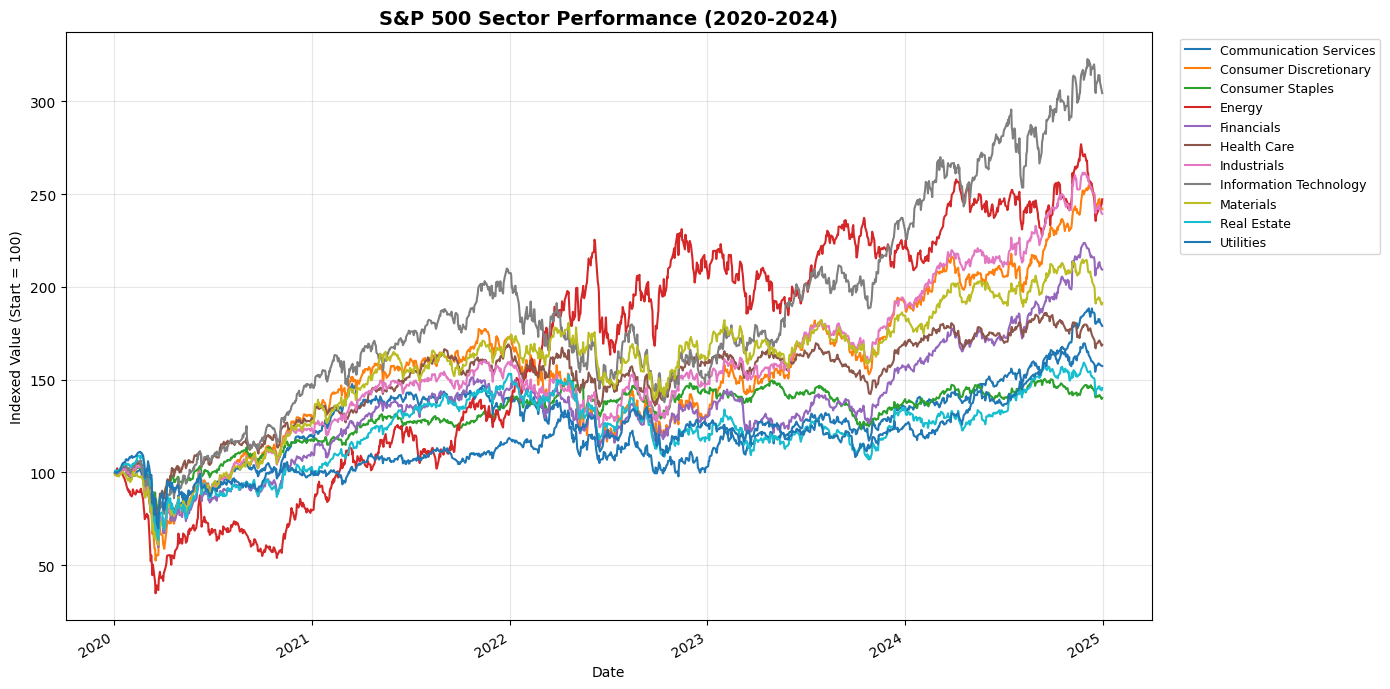

In [2]:
# Compute daily returns
daily_returns = closes.pct_change().dropna(how='all')

# Group columns by sector and average — this gives an equal-weighted sector index
sector_returns = daily_returns.T.groupby(ticker_sectors).mean().T

# Convert to cumulative growth (starting at 100)
sector_cumulative = (1 + sector_returns).cumprod() * 100

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
sector_cumulative.plot(ax=ax, linewidth=1.5)
ax.set_title("S&P 500 Sector Performance (2020-2024)", fontsize=14, fontweight='bold')
ax.set_ylabel("Indexed Value (Start = 100)")
ax.set_xlabel("Date")
ax.grid(alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

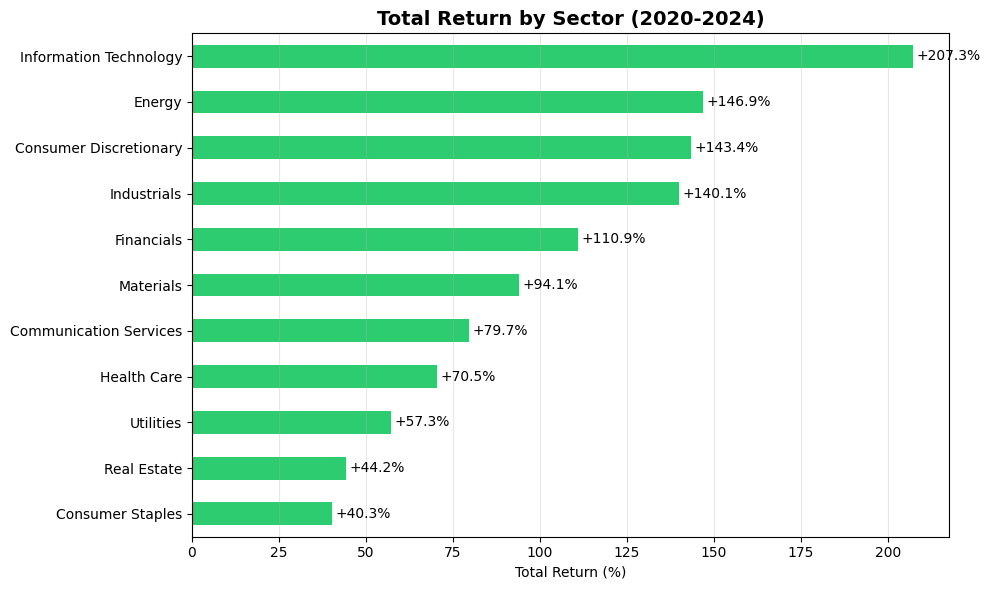


=== Sector Rankings ===
Information Technology    207.3
Energy                    146.9
Consumer Discretionary    143.4
Industrials               140.1
Financials                110.9
Materials                  94.1
Communication Services     79.7
Health Care                70.5
Utilities                  57.3
Real Estate                44.2
Consumer Staples           40.3
dtype: float64


In [3]:
# Total return per sector over the full period
sector_total_return = (sector_cumulative.iloc[-1] / sector_cumulative.iloc[0] - 1) * 100
sector_total_return = sector_total_return.sort_values(ascending=True)

# Horizontal bar chart, colored green/red
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in sector_total_return]

fig, ax = plt.subplots(figsize=(10, 6))
sector_total_return.plot(kind='barh', color=colors, ax=ax)
ax.set_title("Total Return by Sector (2020-2024)", fontsize=14, fontweight='bold')
ax.set_xlabel("Total Return (%)")
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(alpha=0.3, axis='x')

# Add value labels at end of each bar
for i, v in enumerate(sector_total_return):
    ax.text(v + (1 if v > 0 else -1), i, f'{v:+.1f}%',
            va='center', ha='left' if v > 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== Sector Rankings ===")
print(sector_total_return.sort_values(ascending=False).round(1))

=== Risk-Adjusted Performance by Sector ===
                        Annualized Return (%)  Annualized Volatility (%)  \
Information Technology                  26.36                      28.33   
Industrials                             20.38                      23.92   
Consumer Discretionary                  22.00                      29.21   
Financials                              18.46                      26.94   
Energy                                  26.20                      39.84   
Materials                               16.19                      25.15   
Health Care                             12.49                      19.89   
Communication Services                  14.39                      23.29   
Utilities                               11.82                      23.36   
Consumer Staples                         8.18                      16.74   
Real Estate                             11.10                      26.60   

                        Sharpe Ratio  
Info

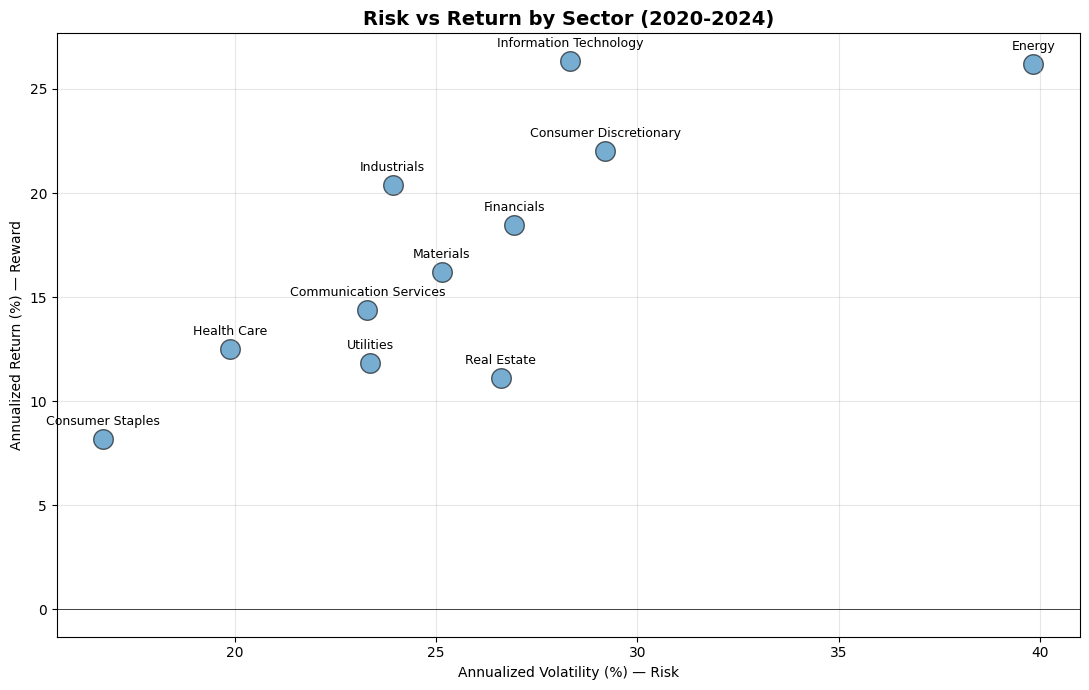

In [4]:
# Annualized return and volatility per sector
ann_return = sector_returns.mean() * 252 * 100
ann_vol = sector_returns.std() * np.sqrt(252) * 100
sharpe = ann_return / ann_vol  # assuming risk-free = 0 for simplicity

risk_return = pd.DataFrame({
    'Annualized Return (%)': ann_return,
    'Annualized Volatility (%)': ann_vol,
    'Sharpe Ratio': sharpe
}).sort_values('Sharpe Ratio', ascending=False)

print("=== Risk-Adjusted Performance by Sector ===")
print(risk_return.round(2))

# Scatter plot: risk vs return
fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(ann_vol, ann_return, s=200, alpha=0.6, edgecolors='black')

for sector in ann_return.index:
    ax.annotate(sector, (ann_vol[sector], ann_return[sector]),
                fontsize=9, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel("Annualized Volatility (%) — Risk")
ax.set_ylabel("Annualized Return (%) — Reward")
ax.set_title("Risk vs Return by Sector (2020-2024)", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

In [5]:
# Total return for every individual stock
stock_total_return = (closes.iloc[-1] / closes.iloc[0] - 1) * 100
stock_total_return = stock_total_return.dropna()

# Best stock per sector
print("=== Best Performer in Each Sector ===\n")
for sector in sorted(ticker_sectors.unique()):
    sector_tickers = ticker_sectors[ticker_sectors == sector].index
    sector_stocks = stock_total_return[stock_total_return.index.isin(sector_tickers)]
    if len(sector_stocks) > 0:
        best = sector_stocks.idxmax()
        best_return = sector_stocks.max()
        print(f"{sector:30s}  {best:6s}  {best_return:+7.1f}%")

=== Best Performer in Each Sector ===

Communication Services          TTD      +333.0%
Consumer Discretionary          TSLA    +1307.9%
Consumer Staples                COST     +242.0%
Energy                          TRGP     +396.5%
Financials                      ARES     +486.4%
Health Care                     LLY      +523.0%
Industrials                     VRT      +916.1%
Information Technology          NVDA    +2148.4%
Materials                       STLD     +274.0%
Real Estate                     IRM      +349.4%
Utilities                       VST      +588.0%


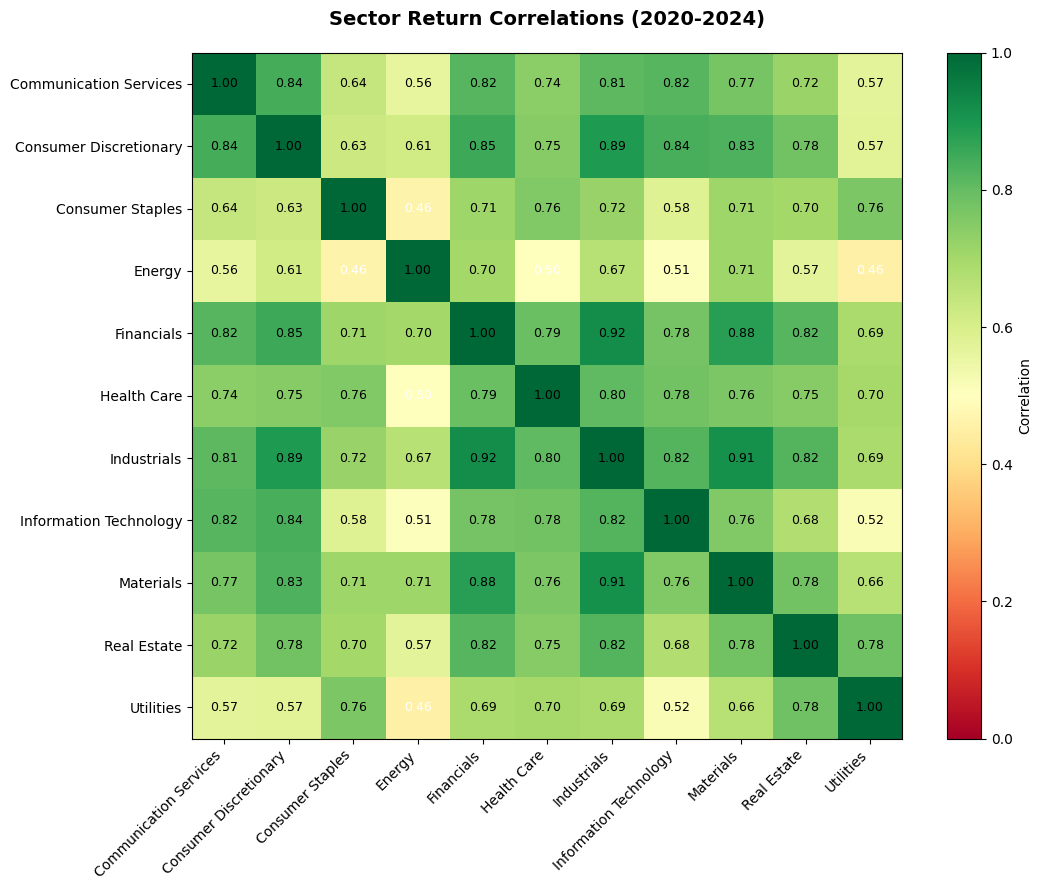

In [6]:
import matplotlib.colors as mcolors

# Correlation matrix between sectors
corr = sector_returns.corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

# Add correlation values to each cell
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black' if corr.iloc[i, j] > 0.5 else 'white')

ax.set_title("Sector Return Correlations (2020-2024)", fontsize=14, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()